In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

/nfs/sw/easybuild/software/custom-conda/ccst-1.0.1/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/sw/easybuild/software/custom-conda/ccst-1.0.1/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/sw/easybuild/software/custom-conda/ccst-1.0.1/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nfs/sw/easybuild/software/custom-conda/ccst-1.0.1/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nfs/sw/easybuild/software/custom-conda/cc

In [2]:
# Load path (path contains seurat object with our annotations)
czi_path = "/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/62_harmony_102224_Seuratv34_newannot_counts.h5ad"

# Read the h5ad file
adata = sc.read_h5ad(czi_path)

print(adata)

AnnData object with n_obs × n_vars = 171459 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopaus

In [3]:
adata.obs["id"].value_counts().head(20).index

Index(['B4P4-CZI04N', 'B4P1-CZI01N', 'B2-CZI14N', 'B3-CZI05N', 'B14-CZI321N',
       'B2-CZI08N', 'B5-CZI24N', 'B3-CZI11N', 'B12-CZI041N', 'B8-CZI020N',
       'B4P1-CZI04N', 'B8-CZI026N', 'B7-CZI027N', 'B11-CZI041N', 'B5-CZI22N',
       'B19-CZI225N', 'B16-CZI182N', 'B10-CZI033N', 'B12-CZI042N',
       'B13-CZI016N'],
      dtype='object', name='id')

In [4]:
len(adata.obs["id"].unique())

65

In [5]:
# Get counts data (scVi requires count info)
adata.layers["counts"] = adata.raw.X.copy()
adata.layers["logcounts"] = adata.X.copy()

In [6]:
# Add HECA annotations to adata (annotation from published HECA dataset)
heca_annot = pd.read_csv("/nfs/home/rfu/projects/CZI_endom/CZI_HECAtype.csv.gz")

# Check if cell index matches
print(pd.Series(adata.obs_names == heca_annot.cell).value_counts())

# Add to anndata
adata.obs["heca_celltype"] = heca_annot["celltype"].values
adata.obs["heca_lineage"] = heca_annot["lineage"].values

True    171459
Name: count, dtype: int64


In [7]:
adata.obs["heca_lineage"].value_counts()

heca_lineage
Epithelial     66407
Endothelial    55773
Mesenchymal    45067
Immune          4212
Name: count, dtype: int64

In [8]:
#Get ensembl IDs - map gene symbol to ensembl ID
gene_ids = pd.read_csv("/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/gene_names_gene_ids_czi_endo.csv", index_col= False)

gene_id_dict = pd.DataFrame({
    'gene_symbol': gene_ids["gene_name"],
    'ensembl_id': gene_ids["gene_id"]})

gene_id_dict = gene_id_dict.set_index('gene_symbol')['ensembl_id'].to_dict()

ensembl_ids = [gene_id_dict.get(gene, 'NA') for gene in adata.var_names]

# Add ensembl IDs to anndata object
adata.var["gene_names"] = adata.var_names
adata.var["ensembl_id"] = ensembl_ids
adata.var_names = ensembl_ids

# Remove duplicated IDs
adata = adata[:, ~adata.var["ensembl_id"].duplicated()].copy()

# Check for duplicated IDs
adata.var["ensembl_id"].duplicated().any()

del adata.varm["HARMONY"]
del adata.varm["PCs"]

In [9]:
#adata_sub = adata[adata.obs['id'].isin(["B15-CZI251N", "B4P1-CZI01N", "B3-CZI11N", "B16-CZI182N", "B8-CZI026N", "B4P4-CZI04N"]) ]
#adata_sub = adata[adata.obs['id'].isin(["B15-CZI251N", "B3-CZI11N", "B8-CZI026N", "B4P4-CZI04N"]) ]

In [144]:
# adata_sub = adata[adata.obs['id'].isin(['B4P4-CZI04N', 'B4P1-CZI01N', 'B2-CZI14N', 'B3-CZI05N', 'B14-CZI321N',
#        'B2-CZI08N', 'B5-CZI24N', 'B3-CZI11N', 'B12-CZI041N', 'B8-CZI020N',
#        'B4P1-CZI04N', 'B8-CZI026N', 'B7-CZI027N', 'B11-CZI041N', 'B5-CZI22N',
#        'B19-CZI225N', 'B16-CZI182N', 'B10-CZI033N', 'B12-CZI042N',
#        'B13-CZI016N']) ]

#adata_sub = adata[adata.obs['id'].isin(["B5-CZI24N", "B5-CZI22N", "B5-CZI34N"])]


In [173]:
adata_sub = adata[adata.obs['heca_lineage'].isin(["Endothelial", "Epithelial", "Mesenchymal"])]

min_cells = 600

# Count per sample per lineage
counts = (
    adata_sub.obs
    .groupby(["id", "heca_lineage"])
    .size()
    .unstack(fill_value=0)
)

# Find samples meeting the criterion in every lineage
select_samples = counts.index[(counts >= min_cells).all(axis=1)]

# Subset adata
adata_sub = adata_sub[adata_sub.obs["id"].isin(select_samples)].copy()

In [186]:
pd.crosstab(
    adata_sub.obs["id"],
    adata_sub.obs["heca_lineage"]
)

heca_lineage,Endothelial,Epithelial,Mesenchymal
id,,,
B10-CZI033N,781,1548,791
B11-CZI041N,1257,724,1555
B12-CZI038N,819,933,663
B12-CZI041N,947,951,1868
B13-CZI039N,1120,929,836
B14-CZI321N,616,1194,2478
B2-CZI08N,2389,605,1286
B3-CZI05N,917,2694,1141
B4P1-CZI04N,891,2230,625


In [187]:
import pandas as pd
import numpy as np

def pseudobulk_by_id_lineage(adata, id_col="id", lineage_col="heca_lineage"):
    """
    Create pseudobulk expression profiles by averaging gene expression within each (id, lineage) group.

    Parameters
    ----------
    adata : AnnData
        AnnData object with cells in `adata.obs` containing id and lineage information.
    id_col : str
        Column name in adata.obs representing the sample or individual ID.
    lineage_col : str
        Column name in adata.obs representing the cell lineage or type.

    Returns
    -------
    pd.DataFrame
        A pseudobulk expression matrix (rows = id_lineage, columns = genes)
        where each value is the mean expression of that gene in the group.
    """
    
    # Ensure required columns exist
    assert id_col in adata.obs.columns, f"'{id_col}' not found in adata.obs"
    assert lineage_col in adata.obs.columns, f"'{lineage_col}' not found in adata.obs"

    # Create a combined group label
    group_labels = adata.obs[id_col].astype(str) + "_" + adata.obs[lineage_col].astype(str)

    # Convert expression matrix to DataFrame
    expr = pd.DataFrame(
        adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X,
        index=adata.obs_names,
        columns=adata.var_names
    )

    # Add group labels
    expr["group"] = group_labels.values

    # Compute mean expression per group
    pseudobulk_df = expr.groupby("group").mean()

    return pseudobulk_df

In [188]:
pb_df = pseudobulk_by_id_lineage(adata_sub)

In [189]:
meta = pd.DataFrame({"sample" : pb_df.index.str.split("_").str[0],
                    "lineage" : pb_df.index.str.split("_").str[1]})

In [190]:
pb_df.index = pb_df.index.str.split("_").str[0]

In [191]:
dfs_by_lineage = {}

for lineage, meta_sub in meta.groupby("lineage"):
    dfs_by_lineage[lineage] = pb_df.iloc[meta_sub.index].copy()   

In [192]:
# from sklearn.cluster import KMeans
# import matplotlib.pyplot as plt

# kmeans_results = {}

In [193]:
adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC',
       'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks',
       'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment',
       'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA',
       'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc',
       'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2',
       'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight',
       'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type',
       'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux',
       'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS',
       'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC',
       'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags',
       'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value',
       'AMULET.q.value', 'AMULET.final', 'ATAC_PASS

In [194]:
adata.obs.id.unique()

array(['B2-CZI14N', 'B2-CZI08N', 'B3-CZI11N', 'B3-CZI05N', 'B3-CZI06N',
       'B3-CZI09N', 'B4P1-CZI01N', 'B4P1-CZI04N', 'B4P4-CZI04N',
       'B5-CZI36N', 'B5-CZI22N', 'B5-CZI24N', 'B5-CZI34N', 'B7-CZI019N',
       'B7-CZI030N', 'B7-CZI027N', 'B7-CZI031N', 'B8-CZI026N',
       'B8-CZI028N', 'B8-CZI020N', 'B8-CZI025N', 'B9-CZI023N',
       'B9-CZI021N', 'B9-CZI015N', 'B9-CZI029N', 'B10-CZI037N',
       'B10-CZI032N', 'B10-CZI033N', 'B10-CZI035N', 'B11-CZI041N',
       'B11-CZI321N', 'B11-CZI350N', 'B11-CZI215N', 'B12-CZI041N',
       'B12-CZI347N', 'B12-CZI042N', 'B12-CZI038N', 'B13-CZI039N',
       'B13-CZI232N', 'B13-CZI016N', 'B13-CZI342N', 'B14-CZI248N',
       'B14-CZI040N', 'B14-CZI245N', 'B14-CZI321N', 'B15-CZI251N',
       'B15-CZI227N', 'B15-CZI238N', 'B15-CZI363N', 'B16-CZI182N',
       'B16-CZI309N', 'B16-CZI295N', 'B16-CZI206N', 'B17-CZI254N',
       'B17-CZI235N', 'B17-CZI222N', 'B17-CZI326N', 'B18-CZI336N',
       'B18-CZI207N', 'B18-CZI229N', 'B18-CZI256N', 'B19-CZI252N

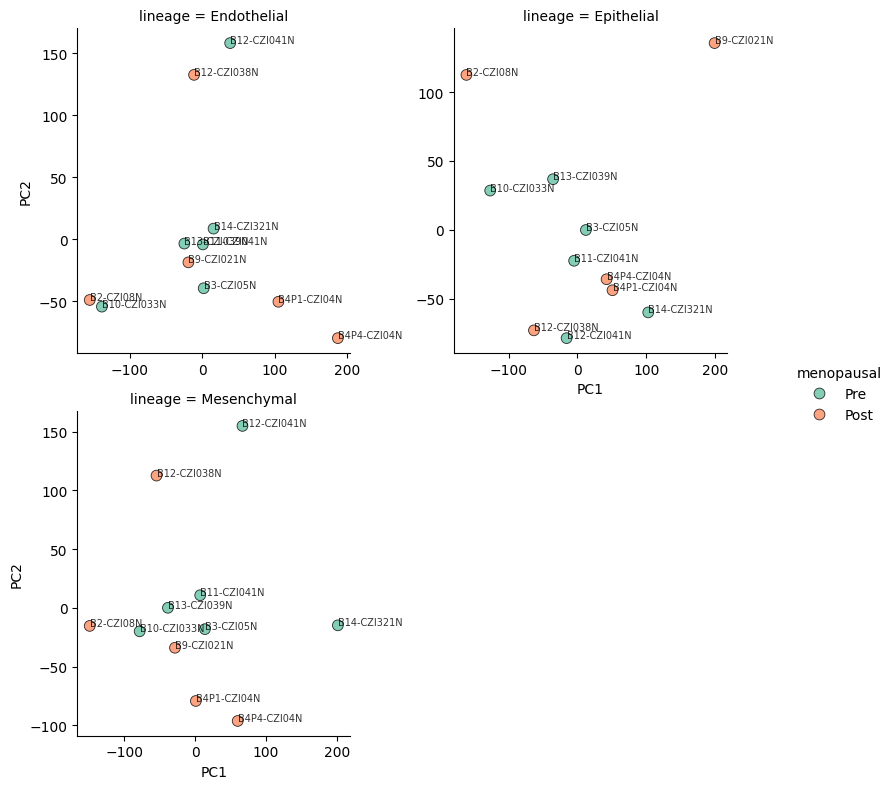

In [195]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

all_pca = []

for lineage, subdf in dfs_by_lineage.items():

    # Scale
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(subdf)

    # PCA
    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(scaled_data)

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42)
    labels = kmeans.fit_predict(scaled_data)

    # Build df
    pca_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=subdf.index)
    pca_df["cluster"] = labels
    pca_df["lineage"] = lineage

    #pca_df.to_csv(f"./tables/first_pcs_plus_kmeans_label_{lineage}.csv")


    all_pca.append(pca_df)

# Combine all lineages
plot_df = pd.concat(all_pca)

color_var = "menopausal"
obs_map = adata.obs.set_index("id")[color_var]

unique_index_mask = ~obs_map.index.duplicated(keep='first')
obs_map = obs_map[unique_index_mask]
#obs_map = pd.concat([obs_map] * 4, ignore_index=False)

plot_df[color_var] = obs_map.loc[plot_df.index].values

highlight_samples = ["B18-CZI256N", "B5-CZI24N", "B5-CZI22N", "B5-CZI34N"]  # <- B8-CZI026N

#"B4P4-CZI04N", "B7-CZI027N", "B18-CZI256N"

plot_df["highlight"] = np.where(
    plot_df.index.isin(highlight_samples),
    "Highlight",
    "Other"
)

# ---- Facet plot ----
g = sns.FacetGrid(
    plot_df,
    col="lineage",
    col_wrap=2,
    height=4,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="PC1",
    y="PC2",
    hue="menopausal",
    palette="Set2",
    s=60,
    alpha=0.8,
    edgecolor="k"
)

for ax, lineage in zip(g.axes.flat, plot_df["lineage"].unique()):
    sub = plot_df[plot_df["lineage"] == lineage]

    for idx, r in sub.iterrows():
        ax.text(
            r["PC1"], r["PC2"], str(idx),
            fontsize=7, alpha=0.8
        )

g.add_legend(title="menopausal")
g.set_axis_labels("PC1", "PC2")
g.tight_layout()

plt.show()

In [185]:
plot_df

,PC1,PC2,cluster,lineage,menopausal,highlight
group,,,,,,
B10-CZI033N,-138.831038,-54.297319,2,Endothelial,Pre,Other
B11-CZI041N,0.830287,-4.181658,0,Endothelial,Pre,Other
B12-CZI038N,-11.363920,132.449128,0,Endothelial,Post,Other
B12-CZI041N,38.600800,158.049914,0,Endothelial,Pre,Other
B13-CZI039N,-24.787520,-3.485606,0,Endothelial,Pre,Other
B14-CZI321N,15.601799,8.556160,0,Endothelial,Pre,Other
B2-CZI08N,-155.710209,-48.938130,2,Endothelial,Post,Other
B3-CZI05N,1.982755,-39.483681,0,Endothelial,Pre,Other
B4P1-CZI04N,105.318871,-50.381102,1,Endothelial,Post,Other


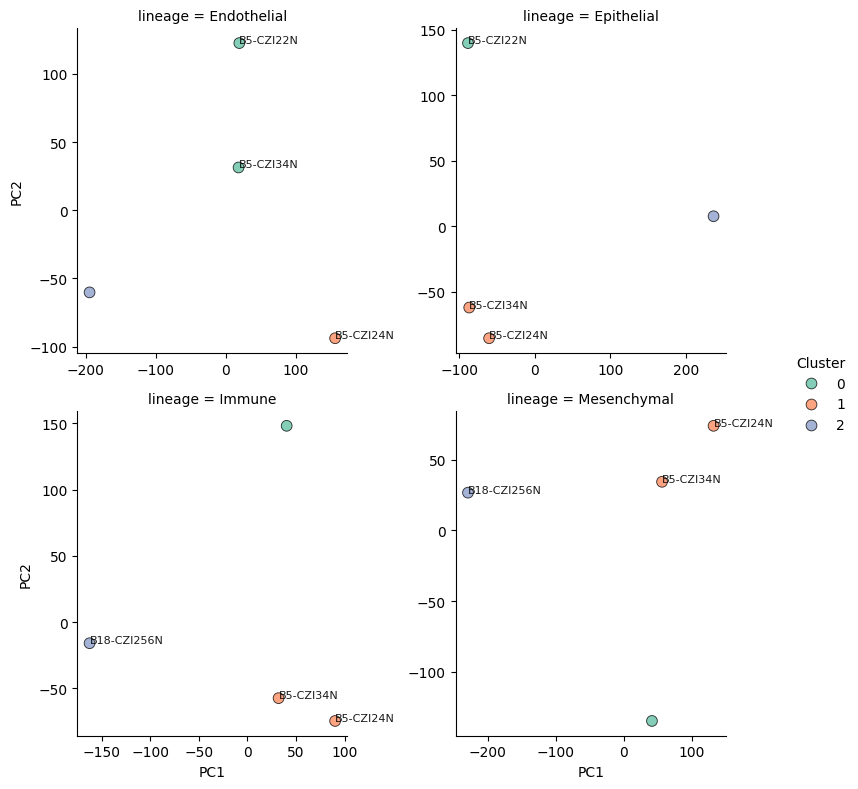

In [127]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

all_pca = []

for lineage, subdf in dfs_by_lineage.items():

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(subdf)

    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(scaled_data)

    kmeans = KMeans(n_clusters=3, random_state=42)
    labels = kmeans.fit_predict(scaled_data)

    pca_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=subdf.index)
    pca_df["cluster"] = labels
    pca_df["lineage"] = lineage

    # ---- find outliers ----
    centers = pd.DataFrame(
        pca.transform(kmeans.cluster_centers_),
        columns=["PC1", "PC2"]
    )

    dists = []
    for i, row in pca_df.iterrows():
        c = centers.loc[row["cluster"]]
        d = np.sqrt((row["PC1"] - c["PC1"])**2 + (row["PC2"] - c["PC2"])**2)
        dists.append(d)

    pca_df["dist"] = dists

    # mark top 2% as outliers
    cutoff = pca_df["dist"].quantile(0.00)
    pca_df["outlier"] = pca_df["dist"] > cutoff

    all_pca.append(pca_df)

plot_df = pd.concat(all_pca)

# ---- Facet plot ----
g = sns.FacetGrid(
    plot_df,
    col="lineage",
    col_wrap=2,
    height=4,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=60,
    alpha=0.8,
    edgecolor="k"
)

# ---- annotate only outliers ----
for ax, lineage in zip(g.axes.flat, plot_df["lineage"].unique()):
    sub = plot_df[plot_df["lineage"] == lineage]
    outs = sub[sub["outlier"]]

    for idx, r in outs.iterrows():
        ax.text(r["PC1"], r["PC2"], str(idx),
                fontsize=8, alpha=0.9)

g.add_legend(title="Cluster")
g.set_axis_labels("PC1", "PC2")
g.tight_layout()
plt.show()

In [26]:
adata.obs["menopausal"].value_counts()

menopausal
Post              100427
Pre                65683
Perimenopausal      5349
Name: count, dtype: int64

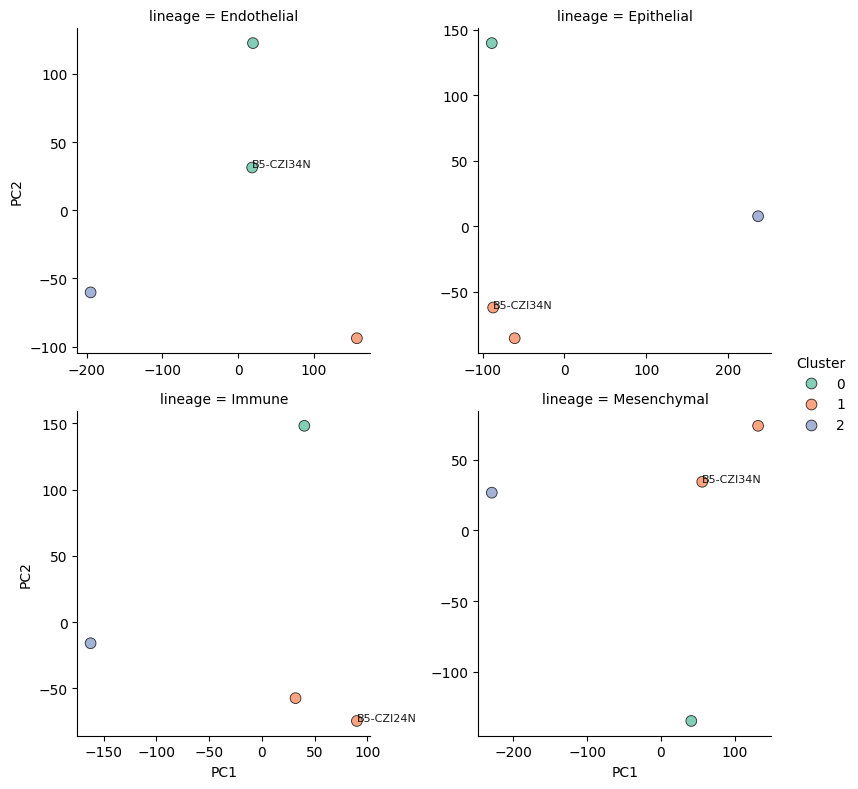

In [126]:
# Color by metadata
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

all_pca = []

for lineage, subdf in dfs_by_lineage.items():

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(subdf)

    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(scaled_data)

    kmeans = KMeans(n_clusters=3, random_state=42)
    labels = kmeans.fit_predict(scaled_data)

    pca_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=subdf.index)
    pca_df["cluster"] = labels
    pca_df["lineage"] = lineage

    # ---- find outliers ----
    centers = pd.DataFrame(
        pca.transform(kmeans.cluster_centers_),
        columns=["PC1", "PC2"]
    )

    dists = []
    for i, row in pca_df.iterrows():
        c = centers.loc[row["cluster"]]
        d = np.sqrt((row["PC1"] - c["PC1"])**2 + (row["PC2"] - c["PC2"])**2)
        dists.append(d)

    pca_df["dist"] = dists

    # mark top 2% as outliers
    cutoff = pca_df["dist"].quantile(0.80)
    pca_df["outlier"] = pca_df["dist"] > cutoff

    all_pca.append(pca_df)

plot_df = pd.concat(all_pca)

# ---- Facet plot ----
g = sns.FacetGrid(
    plot_df,
    col="lineage",
    col_wrap=2,
    height=4,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=60,
    alpha=0.8,
    edgecolor="k"
)

# ---- annotate only outliers ----
for ax, lineage in zip(g.axes.flat, plot_df["lineage"].unique()):
    sub = plot_df[plot_df["lineage"] == lineage]
    outs = sub[sub["outlier"]]

    for idx, r in outs.iterrows():
        ax.text(r["PC1"], r["PC2"], str(idx),
                fontsize=8, alpha=0.9)

g.add_legend(title="Cluster")
g.set_axis_labels("PC1", "PC2")
g.tight_layout()
plt.show()

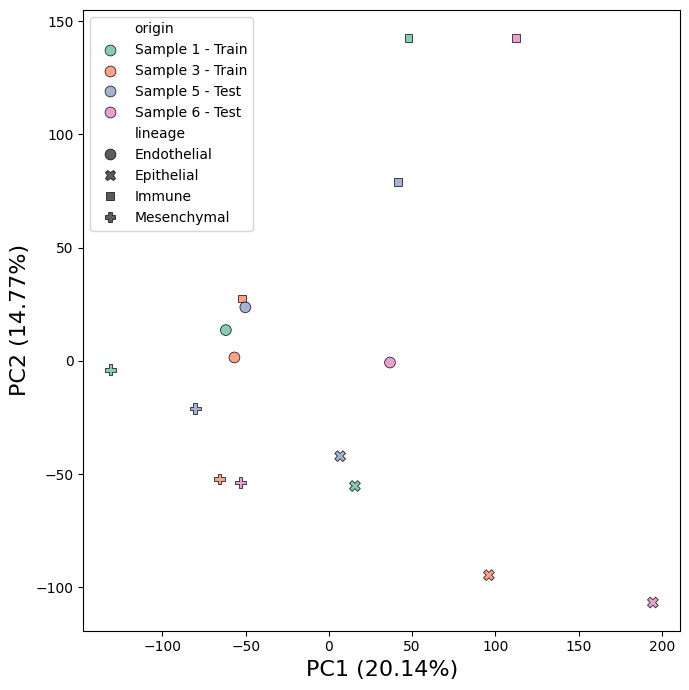

In [26]:
# Drop non-numeric columns if any
# Standardize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pb_df)

# Fit PCA
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(scaled_data)

# Create DataFrame for plotting
pca_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=pb_df.index)
pca_df["sample"] = meta["sample"].values
pca_df["lineage"] = meta["lineage"].values

# mapping = {
#     "B15-CZI251N": "Sample 1 - Train",
#     "B4P1-CZI01N": "Sample 2 - Train",
#     "B3-CZI11N": "Sample 3 - Train", 
#     "B16-CZI182N": "Sample 4 - Train",
#     "B8-CZI026N": "Sample 5 - Test",
#     "B4P4-CZI04N": "Sample 6 - Test", 
#     "B5-CZI22N": "Sample 7 - New",
#     "B11-CZI041N": "Sample 8 - New",
#     "B7-CZI027N": "Sample 9 - New", 
# }

pca_df["origin"] = pca_df["sample"].map(mapping)
pca_df = pca_df.sort_values(by="origin")

plt.figure(figsize=(7, 7))

sns.scatterplot(
    data=pca_df, x="PC1", y="PC2", hue="origin", style="lineage",
    palette="Set2", s=60, alpha=0.8, edgecolor="k"
)

# Add explained variance info
var_exp = pca.explained_variance_ratio_ * 100
plt.xlabel(f"PC1 ({var_exp[0]:.2f}%)",fontsize=16)
plt.ylabel(f"PC2 ({var_exp[1]:.2f}%)", fontsize=16)
plt.legend(title = "")
plt.title("")
plt.tight_layout()
plt.show()

# Get PCA embeddings

In [ ]:
# read signature matrix
# sig_matrix = pd.read_csv('/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data_lineage/train/signature_matrix_for_nnls.csv',
#                          index_col=0)

In [ ]:
# scaler = StandardScaler()
# train_scaled = scaler.fit_transform(pseudobulk_train)

# # Transform the test data using the *fitted* scaler
# test_scaled = scaler.transform(pseudobulk_test)

In [ ]:
#sig_matrix_scaled = scaler.transform(sig_matrix)

In [ ]:
# # Initialize PCA (e.g., to keep 5 components)
# pca = PCA(n_components=100, random_state=42)

# # FIT the PCA ONLY on the scaled training data (to learn the 5 PCs)
# pca_train = pca.fit_transform(train_scaled)

# # Transform the scaled test data using the *fitted* PCA object
# pca_test = pca.transform(test_scaled)

In [ ]:
#pca_sig_matrix = pca.transform(sig_matrix_scaled)

In [ ]:
#pca_train = pd.DataFrame(pca_train)

In [ ]:
#pca_test = pd.DataFrame(pca_test)

In [ ]:
#pca_sig_matrix = pd.DataFrame(pca_sig_matrix)

In [ ]:
#pca_sig_matrix.index = sig_matrix.index

In [ ]:
# pca_train.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data_lineage/train/pca_pseudobulk_train_set.csv")
# pca_test.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data_lineage/test/pca_pseudobulk_test_set.csv")

In [ ]:
#pca_sig_matrix.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data_lineage/train/pca_sig_matrix.csv")

In [ ]:
# gf_sig_matrix = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data_lineage/train/gf_sig_mat_embeddings.csv")
# temp = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data_lineage/train/signature_matrix_for_nnls.csv", index_col=0)